In [1]:
import logomaker
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [16]:
import glob
results_file = glob.glob('/clusterfs/nilah/sergio/RFdifussion/outputs/*/*.csv')
print(len(results_file))

127


In [17]:
import pandas as pd
import os

def aggregate_results(results_files, run_id_level=-2, extra_columns=None):
    """
    Aggregate CSV files into a single DataFrame with run identifiers.
    
    Args:
        results_files (list): List of paths to CSV files.
        run_id_level (int): Directory level to extract run ID (e.g., -2 for parent of filename).
        extra_columns (dict): Optional dictionary of column_name: lambda_function to add metadata.
    
    Returns:
        pd.DataFrame: Concatenated DataFrame with run IDs and optional columns.
    """
    if not results_files:
        print("Warning: No files provided.")
        return pd.DataFrame()

    dfs = []
    for file_path in results_files:
        # try:
        # Read CSV
        tmp = pd.read_csv(file_path)
        
        # Extract run ID from path
        run_id = os.path.split(os.path.dirname(file_path))[run_id_level]
        tmp['RUN'] = run_id
        
        # Add optional columns
        # if extra_columns:
        #     for col_name, func in extra_columns.items():
        #         tmp[col_name] = func(file_path)
        
        dfs.append(tmp)
        print(f"Processed: {file_path}")
    


    # Concatenate all DataFrames
    if dfs:
        results = pd.concat(dfs, axis=0 )# , ignore_index=True)
        print(f"Aggregated {len(dfs)} files into DataFrame with {len(results)} rows.")
        return results
    else:
        print("No valid files processed.")
        return pd.DataFrame()

# Example usage for RFdiffusion results
# results_dir = "/clusterfs/nilah/sergio/RFdifussion/outputs/EPITOPE_SERIES_20250416/*/af2.csv"
results_files = glob.glob('/clusterfs/nilah/sergio/RFdifussion/outputs/*/*.csv')

# # Define extra columns (e.g., extract contigs, iterations, num_seqs from run name)
# extra_columns = {
#     'contigs': lambda x: x.split('/')[-3].split('_C')[1].split('_I')[0],
#     'iterations': lambda x: x.split('_I')[1].split('_NS')[0],
#     'num_seqs': lambda x: x.split('_NS')[1].split('_')[0]
# }

# Aggregate results
results = aggregate_results(results_files, run_id_level=-2) #, extra_columns=extra_columns)

Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD__RUN_v19_C9_I50_NS32/mpnn_results.csv
Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD__RUN_v231_C9_I50_NS32/mpnn_results.csv
Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD__RUN_v23_C8_I50_NS32/mpnn_results.csv
Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD__RUN_v112_C0_I50_NS32/mpnn_results.csv
Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD__RUN_v157_C8_I50_NS32/mpnn_results.csv
Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD__RUN_v13_C1_I50_NS32/mpnn_results.csv
Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD__RUN_v1_C9_I50_NS32/mpnn_results.csv
Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD__RUN_v106_C0_I50_NS32/mpnn_results.csv
Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD__RUN_v135_C8_I50_NS32/mpnn_results.csv
Processed: /clusterfs/nilah/sergio/RFdifussion/outputs/RFD__RUN_v207_C8_I50_NS32/mpnn_results.csv
Processed: /clusterfs/nil

array([[<Axes: title={'center': 'plddt'}>]], dtype=object)

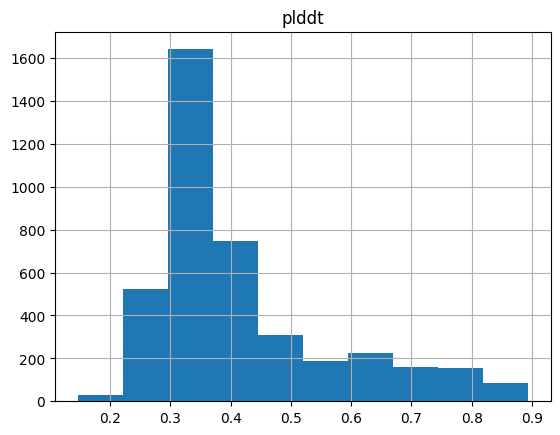

In [18]:
results.hist('plddt')

array([[<Axes: title={'center': 'rmsd'}>]], dtype=object)

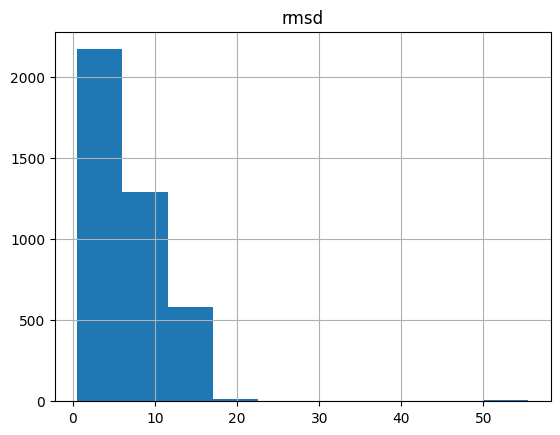

In [19]:
results.hist('rmsd')

array([[<Axes: title={'center': 'i_ptm'}>]], dtype=object)

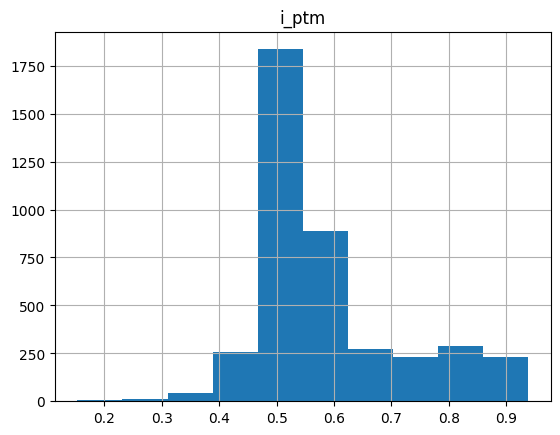

In [20]:
results.hist('i_ptm')

array([[<Axes: title={'center': 'i_pae'}>]], dtype=object)

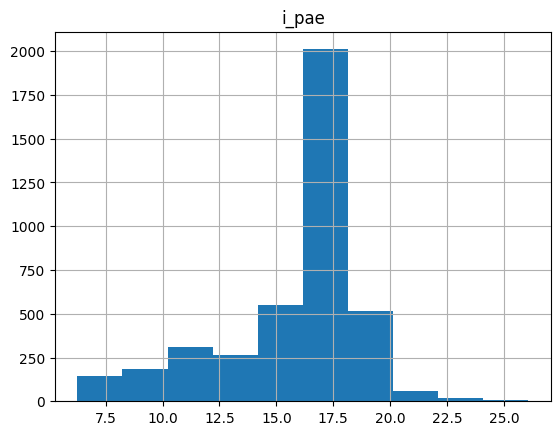

In [21]:
results.hist('i_pae')

In [22]:
# # Filter top sequences by structural confidence
# filtered = results[
#     (results['plddt'] > 0.8) &
#     (results['ptm'] > 0.05) &
#     (results['pae'] < 5.0) &
#     (results['rmsd'] < 2.0)
# ].sort_values(by='plddt', ascending=False)

# print(filtered[['seq', 'plddt', 'ptm', 'pae', 'rmsd', 'mpnn']].head(10))


In [23]:
results['epitope'] = results['seq'].apply(lambda x: x.split("/")[1])
results['length'] = results['epitope'].apply(lambda x: len(x))

In [24]:
results.sort_values(by='plddt', ascending=False)

,Unnamed: 0,design,n,mpnn,plddt,i_ptm,i_pae,rmsd,seq,RUN,epitope,length
14,14,0,14,0.859321,0.894179,0.938261,6.258486,0.906645,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,TALPPPVTIA,10
20,20,0,20,0.806198,0.894179,0.938261,6.258486,0.906645,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,TALPPPVTIA,10
2,2,0,2,0.679514,0.886674,0.933066,6.362588,1.342968,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,HMPPVVPPF,9
21,21,0,21,0.817857,0.884598,0.934739,6.355010,0.891339,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,SALPPPVTIA,10
2,2,0,2,0.869266,0.884265,0.930550,6.323713,0.880663,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,SALPPAVTIA,10
...,...,...,...,...,...,...,...,...,...,...,...,...
26,26,0,26,1.043016,0.185586,0.305499,22.832831,4.027675,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,MVFVLEVEQ,9
21,21,0,21,1.008159,0.185586,0.305499,22.832831,4.027675,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,MVFVLEVEQ,9
10,10,0,10,1.300927,0.180908,0.269224,23.062642,8.170378,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,ATNELVAE,8
18,18,0,18,1.056785,0.170440,0.208988,25.026665,9.766815,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/clusterfs/nilah/sergio/RFdifussion/outputs,MVYVLEVEQ,9


In [25]:
import seaborn as sns

<Axes: xlabel='length', ylabel='plddt'>

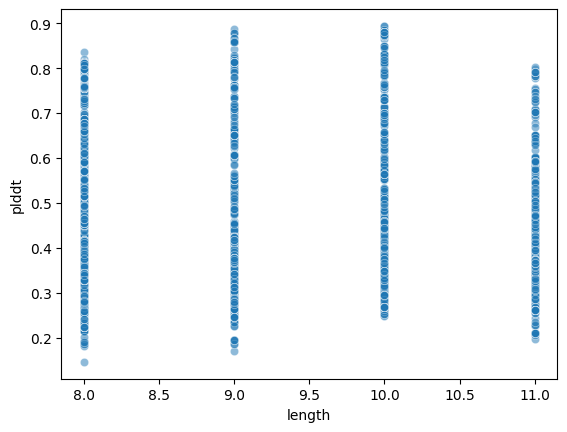

In [26]:
sns.scatterplot(data=results, x='length', y='plddt', alpha=0.5)

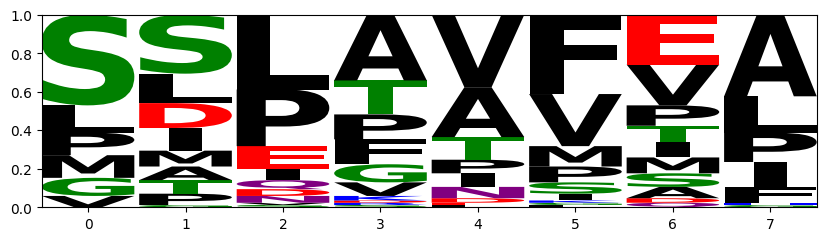

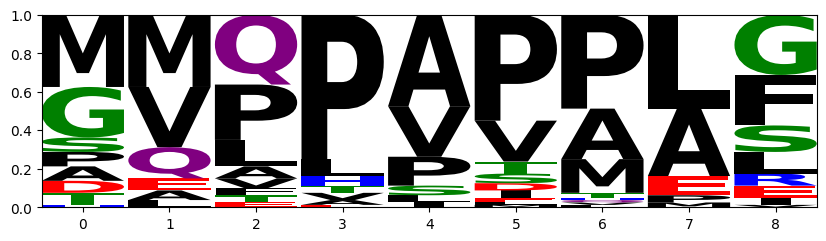

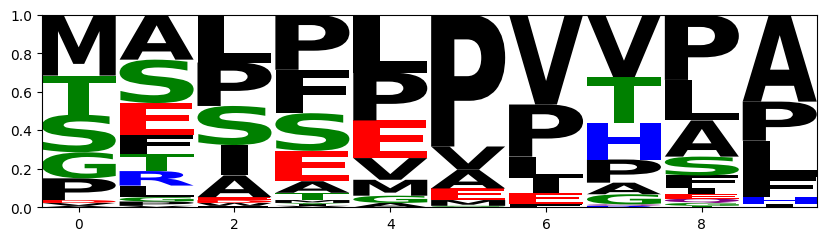

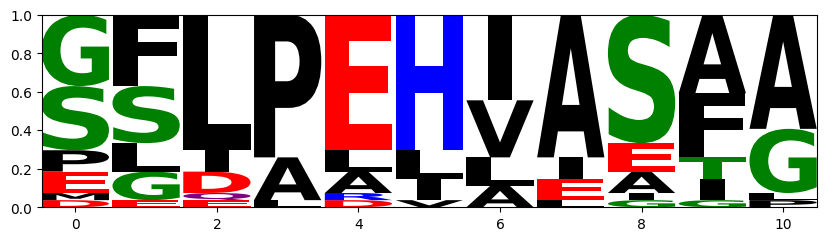

In [30]:
for n in range(8, 12):

    seq_length = n

    sequences = results[(results['epitope'].str.len() == seq_length) & (results['plddt'] > 0.7)]['epitope'].tolist()

    # Create a list of amino acids (standard 20 amino acids)
    amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

    freq_matrix = np.zeros((seq_length, len(amino_acids)))

    # Populate the frequency matrix: count occurrences of each amino acid at each position
    for seq in sequences:
        for i, aa in enumerate(seq):
            aa_index = amino_acids.index(aa)
            freq_matrix[i, aa_index] += 1

    # Normalize the frequency matrix to get probabilities (frequencies sum to 1 at each position)
    freq_matrix = freq_matrix / len(sequences)

    # Create a DataFrame for logomaker
    freq_df = pd.DataFrame(freq_matrix, columns=amino_acids)

    # Generate the sequence logo
    logo = logomaker.Logo(freq_df, color_scheme='chemistry') #, font_name='Arial Rounded MT Bold')


In [28]:
from Bio.PDB import PDBParser, NeighborSearch, is_aa
from scipy.spatial.distance import cdist  # optional but handy
import numpy as np

pdb_file = "/clusterfs/nilah/sergio/RFdifussion/RFdiffusion/structures/7RTD.pdb"
cutoff    = 5.0  # Å

parser = PDBParser(QUIET=True)
structure = parser.get_structure("7RTD", pdb_file)[0]   # first model

atoms_A = [a for a in structure["A"].get_atoms() if a.element != "H"]
atoms_C = [a for a in structure["C"].get_atoms() if a.element != "H"]

# Fast neighbour lookup
ns = NeighborSearch(atoms_A + atoms_C)
contact_pairs = set()

for atom in atoms_A:
    for close_atom in ns.search(atom.coord, cutoff):
        if close_atom in atoms_C:
            resA = atom.get_parent()
            resC = close_atom.get_parent()
            contact_pairs.add((resA, resC))

print(f"{len(contact_pairs)} residue–residue contacts within {cutoff} Å")

# (Optional) list them nicely
for rA, rC in sorted(contact_pairs, key=lambda x: (x[0].id[1], x[1].id[1])):
    # Compute the minimum heavy‑atom distance between the two residues
    coords_A = np.array([a.coord for a in rA if a.element != "H"])
    coords_C = np.array([a.coord for a in rC if a.element != "H"])
    mindist  = cdist(coords_A, coords_C).min()
    print(f"A{rA.id[1]} {rA.resname}  ↔  C{rC.id[1]} {rC.resname}   ({mindist:.2f} Å)")


104 residue–residue contacts within 5.0 Å
A5 MET  ↔  C1 TYR   (3.96 Å)
A7 TYR  ↔  C1 TYR   (2.80 Å)
A7 TYR  ↔  C2 LEU   (3.60 Å)
A9 PHE  ↔  C2 LEU   (3.72 Å)
A33 PHE  ↔  C1 TYR   (4.42 Å)
A45 MET  ↔  C2 LEU   (3.51 Å)
A59 TYR  ↔  C1 TYR   (4.16 Å)
A63 GLU  ↔  C1 TYR   (3.43 Å)
A63 GLU  ↔  C2 LEU   (2.95 Å)
A65 ARG  ↔  C102 HOH   (3.77 Å)
A65 ARG  ↔  C103 HOH   (4.69 Å)
A66 LYS  ↔  C1 TYR   (3.36 Å)
A66 LYS  ↔  C2 LEU   (2.80 Å)
A66 LYS  ↔  C3 GLN   (3.80 Å)
A66 LYS  ↔  C4 PRO   (3.79 Å)
A66 LYS  ↔  C102 HOH   (3.09 Å)
A66 LYS  ↔  C103 HOH   (4.84 Å)
A66 LYS  ↔  C105 HOH   (3.32 Å)
A67 VAL  ↔  C2 LEU   (3.45 Å)
A69 ALA  ↔  C6 THR   (4.29 Å)
A69 ALA  ↔  C101 HOH   (3.66 Å)
A69 ALA  ↔  C103 HOH   (3.39 Å)
A69 ALA  ↔  C105 HOH   (4.02 Å)
A70 HIS  ↔  C2 LEU   (4.16 Å)
A70 HIS  ↔  C3 GLN   (3.29 Å)
A70 HIS  ↔  C5 ARG   (4.71 Å)
A70 HIS  ↔  C6 THR   (3.56 Å)
A70 HIS  ↔  C105 HOH   (2.98 Å)
A73 THR  ↔  C6 THR   (2.67 Å)
A73 THR  ↔  C7 PHE   (3.90 Å)
A73 THR  ↔  C8 LEU   (3.69 Å)
A73 THR  ↔  C1

Name | What it captures | Threshold (after ≤ 5 Å cutoff) | hotspot = "…", ready to copy
core_hotspot | Only the strongest binding hot‑spots—absolute core you almost never want to mutate. |  ≥ 4 distinct protein contacts | "A66,A70,A159"
high_contact | Core + secondary hubs. Good default when you want to preserve the bulk of the binding energy. |  ≥ 3 contacts | "A66,A70,A73,A77,A97,A147,A159"
medium_contact | Moderately important residues; nice to keep fixed if you want a very native‑like interface. |  = 2 contacts | "A7,A63,A99,A116,A143,A146,A155,A156"
low_contact | Peripheral/edge residues; usually safe to let RFdiffusion mutate for better packing/solubility. |  = 1 contact | "A5,A9,A33,A45,A59,A67,A69,A76,A80,A81,A84,A95,A114,A123,A124,A142,A152,A160,A163,A167,A171"
combo_high_low | Lock the high‑energy core while leaving medium residues flexible (high + low combined). | see above | "A5,A9,A33,A45,A59,A66,A67,A69,A70,A73,A76,A77,A80,A81,A84,A95,A97,A114,A123,A124,A142,A147,A152,A159"
all_contacts | Every chain‑A residue that has ≥ 1 heavy‑atom within 5 Å of chain C (36 total). Use to freeze the entire native interface. |  ≥ 1 contact | "A5,A7,A9,A33,A45,A59,A63,A66,A67,A69,A70,A73,A76,A77,A80,A81,A84,A95,A97,A99,A114,A116,A123,A124,A142,A143,A146,A147,A152,A155,A156,A159,A160,A163,A167,A171"
user_hotspot | Your original 9‑residue list. | (user‑defined) | "A7,A9,A59,A63,A66,A70,A99,A159,A167"